# TranAD

**Auteur**: `Jakob De Vreese`  
**Bachelorproef**: Overdraagbare unsupervised anomaliedetectie bij hybride HVAC-systemen  
**Academiejaar**: `2025-2026`

Doel: implementatie van **TranAD (Tuli et al., 2022)** in Keras. Zie de originele paper: https://arxiv.org/abs/2201.07284. Deze notebook implementeert een Keras-versie die zo dicht mogelijk tegen de paper aanligt: één encoder, twee decoders, focus-score self-conditioning en two-phase adversarial training. 

Kort: we gebruiken Keras Model subclassing voor reproduceerbare training, KerasTuner voor een compacte hyperparametertuning en een finale, faithful two-phase trainroutine voor het beste model.

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, Model
import keras_tuner as kt
import os
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    accuracy_score,
    balanced_accuracy_score,
    matthews_corrcoef,
)

2026-05-05 17:19:57.272689: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Gemeenschappelijke evaluatie-toolbox voor alle architecturen (TranAD / encoder-only / dv-mppca)
def make_window_labels(y_timestep, window_size, stride=1, mode='fraction', frac_threshold=0.2):
    y_timestep = np.asarray(y_timestep).astype(int)
    labels = []
    for i in range(0, len(y_timestep) - window_size + 1, stride):
        w = y_timestep[i:i + window_size]
        if mode == 'max':
            labels.append(int(np.max(w) > 0))
        elif mode == 'center':
            labels.append(int(w[window_size // 2] > 0))
        elif mode == 'fraction':
            labels.append(int(np.mean(w) >= frac_threshold))
        else:
            raise ValueError("mode moet 'max', 'center' of 'fraction' zijn")
    return np.asarray(labels, dtype=int)


def find_event_segments(y_binary):
    y = np.asarray(y_binary).astype(int)
    segments = []
    in_seg = False
    start = 0
    for idx, v in enumerate(y):
        if v == 1 and not in_seg:
            in_seg = True
            start = idx
        elif v == 0 and in_seg:
            segments.append((start, idx - 1))
            in_seg = False
    if in_seg:
        segments.append((start, len(y) - 1))
    return segments


def event_based_metrics(y_true_binary, y_pred_binary):
    true_events = find_event_segments(y_true_binary)
    pred_events = find_event_segments(y_pred_binary)

    matched_true = 0
    for ts, te in true_events:
        overlap = any(not (pe < ts or ps > te) for ps, pe in pred_events)
        matched_true += int(overlap)

    matched_pred = 0
    for ps, pe in pred_events:
        overlap = any(not (te < ps or ts > pe) for ts, te in true_events)
        matched_pred += int(overlap)

    event_recall = matched_true / len(true_events) if len(true_events) else 0.0
    event_precision = matched_pred / len(pred_events) if len(pred_events) else 0.0
    if event_precision + event_recall == 0:
        event_f1 = 0.0
    else:
        event_f1 = 2.0 * event_precision * event_recall / (event_precision + event_recall)

    return {
        'event_precision': event_precision,
        'event_recall': event_recall,
        'event_f1': event_f1,
        'n_true_events': len(true_events),
        'n_pred_events': len(pred_events),
        'matched_true_events': matched_true,
        'matched_pred_events': matched_pred,
    }


def build_reusable_scorecard(y_true_window, scores_window, threshold, model_name='model'):
    y_true_window = np.asarray(y_true_window).astype(int)
    scores_window = np.asarray(scores_window).astype(float)
    y_pred_window = (scores_window > threshold).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true_window, y_pred_window, average='binary', zero_division=0
    )

    cm = confusion_matrix(y_true_window, y_pred_window)
    accuracy = accuracy_score(y_true_window, y_pred_window)
    balanced_acc = balanced_accuracy_score(y_true_window, y_pred_window)
    mcc = matthews_corrcoef(y_true_window, y_pred_window)
    roc_auc = roc_auc_score(y_true_window, scores_window) if len(np.unique(y_true_window)) > 1 else np.nan
    pr_auc = average_precision_score(y_true_window, scores_window) if len(np.unique(y_true_window)) > 1 else np.nan

    evt = event_based_metrics(y_true_window, y_pred_window)

    metrics_df = pd.DataFrame({
        'Model': [model_name] * 11,
        'Metric': [
            'Accuracy', 'Balanced Accuracy', 'Precision', 'Recall', 'F1',
            'MCC', 'ROC-AUC', 'PR-AUC', 'Event Precision', 'Event Recall', 'Event F1'
        ],
        'Value': [
            accuracy, balanced_acc, precision, recall, f1,
            mcc, roc_auc, pr_auc, evt['event_precision'], evt['event_recall'], evt['event_f1']
        ]
    })

    return {
        'threshold': float(threshold),
        'metrics_df': metrics_df,
        'confusion_matrix': cm,
        'y_pred_window': y_pred_window,
        'event_details': evt,
    }


def tune_threshold_by_f1(scores, y_true, q_low=0.90, q_high=0.999, n=250):
    scores = np.asarray(scores).astype(float)
    y_true = np.asarray(y_true).astype(int)
    candidates = np.unique(np.quantile(scores, np.linspace(q_low, q_high, n)))

    best_t = float(candidates[0])
    best_f1 = -1.0
    for t in candidates:
        y_hat = (scores > t).astype(int)
        _, _, f1, _ = precision_recall_fscore_support(y_true, y_hat, average='binary', zero_division=0)
        if f1 > best_f1:
            best_f1 = float(f1)
            best_t = float(t)
    return best_t, best_f1


def score_windows_tranad(model, X, batch_size=32, score_mode='quantile_l1_sum', quantile=0.9, last_k=24):
    X_tf = tf.cast(X, tf.float32)
    rec1, rec2 = model.predict(X_tf, batch_size=batch_size, verbose=0)
    abs_err_sum = np.sum(np.abs(rec2 - X), axis=-1)

    if score_mode == 'mean_l1_sum':
        scores = np.mean(abs_err_sum, axis=1)
    elif score_mode == 'quantile_l1_sum':
        scores = np.quantile(abs_err_sum, quantile, axis=1)
    elif score_mode == 'lastk_l1_sum':
        k = int(min(max(last_k, 1), abs_err_sum.shape[1]))
        scores = np.mean(abs_err_sum[:, -k:], axis=1)
    else:
        raise ValueError('Onbekende score_mode')

    return rec1, rec2, scores

## Pipeline-overzicht (lineair en vergelijkbaar met encoder-only)

Deze notebook volgt nu expliciet een lineaire flow met kleine, idempotente cellen:

1. Gemeenschappelijke evaluatie-tools (gedeeld met encoder-only en dv-mppca)
2. Data-inname en preprocessing
3. TranAD-architectuur
4. Baseline training
5. Hyperparameter tuning
6. Evaluatie met uniforme scorekaart (window + event)
7. Threshold-kalibratie en finale rapportering

Gebruik bij voorkeur deze volgorde van boven naar beneden; zo blijft de vergelijking tussen modellen consistent.

## STAP 1 - Data Preprocessing (Sliding Windows)

TranAD (Tuli et al., 2022) is een model dat, net als de eerste Transformer in deze reeks, werkt met **temporale sequenties**. Het model analyseert niet één enkel meetpunt, maar een aaneengesloten periode (een *sliding window*) om de context en langetermijntrends van het HVAC-systeem te begrijpen.

In deze stap lezen we de data in, normaliseren we deze via standaardisatie (omdat neurale netwerken gevoelig zijn voor schaalverschillen tussen sensoren), en transformeren we de 2D-tabel naar een 3D-tensor van overlappende windows.

### 1.1 Dataset inlezen

In [3]:
# Dataset inlezen
GEBOUW = 'dunant1'

url = f'../02_eda_en_ground_truth/processed/{GEBOUW}_train.csv'
data = pd.read_csv(url)
data.head()

,timestamp,f_1,f_2,f_3,f_4,f_6,f_7,f_8,f_9,f_10,...,f_50,f_51,f_52,f_53,f_54,f_55,is_weekdag,is_weekend,is_werkuur,uur
0,2026-03-09 00:10:00+00:00,7.0,0.77,1.0,39.877285,31.832268,1.0,23.594538,44.640636,1.0,...,0.0,3.851797,99.589400,0.749325,86.946641,0.0,1,0,0,0
1,2026-03-09 00:20:00+00:00,9.0,0.78,1.0,41.921010,34.104786,1.0,46.930084,44.640636,1.0,...,0.0,3.903977,100.000000,0.559565,45.771835,0.0,1,0,0,0
2,2026-03-09 00:30:00+00:00,8.0,0.86,1.0,43.412975,35.585346,1.0,43.235270,44.640636,0.0,...,0.0,4.244891,99.196013,0.322963,91.228401,0.0,1,0,0,0
3,2026-03-09 00:40:00+00:00,7.0,0.78,1.0,43.734930,35.924030,1.0,48.845810,44.640636,0.0,...,0.0,4.448537,98.800579,0.300000,323.796930,0.0,1,0,0,0
4,2026-03-09 00:50:00+00:00,9.0,0.78,1.0,44.037724,36.229050,1.0,44.068630,44.640636,0.0,...,0.0,4.748848,99.259927,0.345344,204.933704,0.0,1,0,0,0


In [4]:
print(data.shape)

(4146, 59)


### 1.2 Chronologische Train/Test split (80/20)

In [5]:
# Drop timestamp
if 'timestamp' in data.columns:
    data = data.drop(columns='timestamp')

# Splitsen in training en test (80% en 20%)
split_index = int(len(data) * 0.8)
train_data = data.iloc[:split_index]
test_data = data.iloc[split_index:]

print(f"Train data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

Train data shape: (3316, 58)
Test data shape: (830, 58)


### 1.3 Normalisatie van de data

In [6]:
scaler = StandardScaler()
train_norm = scaler.fit_transform(train_data)
test_norm = scaler.transform(test_data) # Pas de normalisatie ook toe op de testdata

### 1.4 Sliding windows maken

In [7]:
WINDOW_SIZE = 144   # 1 dag data op 10-minutenbasis

In [8]:
# Hulpfunctie
def create_windows(data_array, window_size, step=1):
    windows = []
    for i in range(0, len(data_array) - window_size + 1, step):
        windows.append(data_array[i : i + window_size])
    return np.array(windows)

In [9]:
X_train_all = create_windows(train_norm, WINDOW_SIZE)
X_test = create_windows(test_norm, WINDOW_SIZE)

# Extra validatieset uit het einde van de train windows (chronologisch, geen shuffle)
val_ratio = 0.15
val_start = int(len(X_train_all) * (1 - val_ratio))
X_train = X_train_all[:val_start]
X_val = X_train_all[val_start:]

print(f"Vorm van de training data (X_train): {X_train.shape}")
print(f"Vorm van de validatie data (X_val): {X_val.shape}")
print(f"Vorm van de test data (X_test): {X_test.shape}")

Vorm van de training data (X_train): (2697, 144, 58)
Vorm van de validatie data (X_val): (476, 144, 58)
Vorm van de test data (X_test): (687, 144, 58)


## STAP 2 - TranAD Architectuur (Keras, faithful)

We implementeren TranAD met de kerncomponenten uit de paper:
- Eén shared encoder
- Twee onafhankelijke decoders
- Learnable positional encoding
- Focus-score zelf-conditioning (|O1 - W|)

De exacte two-phase adversarial training (Encoder+Decoder1 vs Decoder2) wordt uitgevoerd in `fit_tranad` zodat de training vergelijkbaar is met het originele werk, maar geschreven in Keras/TensorFlow.

In [10]:
DIM_MODEL = 128
NUM_HEADS = 8
NUM_LAYERS = 1
FFN_EXPANSION = 4
DROPOUT_RATE = 0.1

# TranAD two-phase weging: start meer fase-1, schuif gradueel naar fase-2
ALPHA_PHASE1_START = 0.6
ALPHA_PHASE1_END = 0.1

### 2.1 Transformer Encoder Laag

In [11]:
class TransformerEncoderLayer(layers.Layer):
    def __init__(self, d_model, num_heads, ffn_expansion=4, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.mha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)
        self.ffn = tf.keras.Sequential([
            layers.Dense(d_model * ffn_expansion, activation='relu'),
            layers.Dropout(dropout_rate),
            layers.Dense(d_model),
        ])
        self.dropout1 = layers.Dropout(dropout_rate)
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)

    def call(self, x, training=False):
        attn_output = self.mha(x, x, training=training)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)

        ffn_output = self.ffn(out1, training=training)
        return self.layernorm2(out1 + ffn_output)

### 2.2 Transformer Decoder Laag

In [12]:
class TransformerDecoderLayer(layers.Layer):
    def __init__(self, d_model, num_heads, ffn_expansion=4, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.self_attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)
        self.cross_attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)

        self.ffn = tf.keras.Sequential([
            layers.Dense(d_model * ffn_expansion, activation='relu'),
            layers.Dropout(dropout_rate),
            layers.Dense(d_model),
        ])

        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm3 = layers.LayerNormalization(epsilon=1e-6)

    def call(self, x, memory, training=False):
        attn1 = self.self_attn(x, x, training=training)
        attn1 = self.dropout1(attn1, training=training)
        out1 = self.layernorm1(x + attn1)

        attn2 = self.cross_attn(query=out1, value=memory, key=memory, training=training)
        attn2 = self.dropout2(attn2, training=training)
        out2 = self.layernorm2(out1 + attn2)

        ffn_output = self.ffn(out2, training=training)
        return self.layernorm3(out2 + ffn_output)

### 2.3 TranAD model met custom train/test step

In [13]:
class TranAD(Model):
    def __init__(
        self,
        num_features,
        d_model=DIM_MODEL,
        num_heads=NUM_HEADS,
        num_layers=NUM_LAYERS,
        ffn_expansion=FFN_EXPANSION,
        dropout_rate=DROPOUT_RATE,
        alpha_phase1_start=ALPHA_PHASE1_START,
        alpha_phase1_end=ALPHA_PHASE1_END,
        total_epochs=12,
        window_size=WINDOW_SIZE,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.alpha_phase1_start = float(alpha_phase1_start)
        self.alpha_phase1_end = float(alpha_phase1_end)
        self.total_epochs = int(total_epochs)
        self.current_epoch = tf.Variable(0.0, trainable=False, dtype=tf.float32)

        self.input_projection = layers.Dense(d_model)
        self.focus_projection = layers.Dense(d_model)

        self.positional_encoding = self.add_weight(
            shape=(1, window_size, d_model),
            initializer='random_normal',
            trainable=True,
            name='positional_encoding',
        )

        self.encoder_layers = [
            TransformerEncoderLayer(
                d_model=d_model,
                num_heads=num_heads,
                ffn_expansion=ffn_expansion,
                dropout_rate=dropout_rate,
            )
            for _ in range(num_layers)
        ]

        self.decoder1 = TransformerDecoderLayer(
            d_model=d_model,
            num_heads=num_heads,
            ffn_expansion=ffn_expansion,
            dropout_rate=dropout_rate,
        )
        self.decoder2 = TransformerDecoderLayer(
            d_model=d_model,
            num_heads=num_heads,
            ffn_expansion=ffn_expansion,
            dropout_rate=dropout_rate,
        )

        self.output_projection1 = layers.Dense(num_features)
        self.output_projection2 = layers.Dense(num_features)

        self.loss_tracker = tf.keras.metrics.Mean(name='loss')
        self.phase1_tracker = tf.keras.metrics.Mean(name='phase1_loss')
        self.phase2_tracker = tf.keras.metrics.Mean(name='phase2_loss')
        self.alpha_tracker = tf.keras.metrics.Mean(name='alpha_phase1')

    @property
    def metrics(self):
        return [
            self.loss_tracker,
            self.phase1_tracker,
            self.phase2_tracker,
            self.alpha_tracker,
        ]

    def set_epoch(self, epoch):
        self.current_epoch.assign(float(epoch))

    def _current_alpha(self):
        denom = tf.cast(tf.maximum(self.total_epochs - 1, 1), tf.float32)
        progress = tf.clip_by_value(self.current_epoch / denom, 0.0, 1.0)
        alpha = self.alpha_phase1_start + (self.alpha_phase1_end - self.alpha_phase1_start) * progress
        return tf.clip_by_value(alpha, 0.0, 1.0)

    def _forward_phase(self, x, focus_score, training=False):
        x_proj = self.input_projection(x)
        focus_proj = self.focus_projection(focus_score)

        z = x_proj + focus_proj + self.positional_encoding
        for enc in self.encoder_layers:
            z = enc(z, training=training)

        tgt = x_proj + self.positional_encoding
        out1 = self.decoder1(tgt, z, training=training)
        out2 = self.decoder2(tgt, z, training=training)

        rec1 = self.output_projection1(out1)
        rec2 = self.output_projection2(out2)
        return rec1, rec2

    def call(self, x, training=False):
        focus_zero = tf.zeros_like(x)
        rec1, _ = self._forward_phase(x, focus_zero, training=training)

        focus_score = tf.abs(rec1 - x)
        _, rec2_hat = self._forward_phase(x, focus_score, training=training)
        return rec1, rec2_hat

    def train_step(self, data):
        batch_x = data[0] if isinstance(data, tuple) else data

        with tf.GradientTape() as tape:
            rec1, rec2_hat = self(batch_x, training=True)
            phase1_loss = tf.reduce_mean(tf.square(rec1 - batch_x))
            phase2_loss = tf.reduce_mean(tf.square(rec2_hat - batch_x))
            alpha_phase1 = self._current_alpha()
            loss = (alpha_phase1 * phase1_loss) + ((1.0 - alpha_phase1) * phase2_loss)

        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.loss_tracker.update_state(loss)
        self.phase1_tracker.update_state(phase1_loss)
        self.phase2_tracker.update_state(phase2_loss)
        self.alpha_tracker.update_state(alpha_phase1)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        batch_x = data[0] if isinstance(data, tuple) else data
        rec1, rec2_hat = self(batch_x, training=False)

        phase1_loss = tf.reduce_mean(tf.square(rec1 - batch_x))
        phase2_loss = tf.reduce_mean(tf.square(rec2_hat - batch_x))
        alpha_phase1 = self._current_alpha()
        loss = (alpha_phase1 * phase1_loss) + ((1.0 - alpha_phase1) * phase2_loss)

        self.loss_tracker.update_state(loss)
        self.phase1_tracker.update_state(phase1_loss)
        self.phase2_tracker.update_state(phase2_loss)
        self.alpha_tracker.update_state(alpha_phase1)
        return {m.name: m.result() for m in self.metrics}


class TranADPhaseScheduler(tf.keras.callbacks.Callback):
    def __init__(self, total_epochs):
        super().__init__()
        self.total_epochs = total_epochs

    def on_epoch_begin(self, epoch, logs=None):
        _ = logs
        if hasattr(self.model, 'set_epoch'):
            self.model.set_epoch(epoch)

In [14]:
# Instantiëren ter controle
NUM_FEATURES = X_train.shape[-1]
model = TranAD(num_features=NUM_FEATURES)

# Dummy data voorwaarts sturen om grafiek te bouwen
dummy_x = tf.zeros((1, WINDOW_SIZE, NUM_FEATURES))
_ = model(dummy_x)

model.summary()

Model: "tran_ad"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (1, 144, 128)          │         7,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 144, 128)          │         7,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_layer       │ ?                      │       198,272 │
│ (TransformerEncoderLayer)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_decoder_layer       │ ?                      │       264,576 │
│ (TransformerDecoderLayer)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_decoder_layer_1     │ ?                      │       264,576 │
│ (TransformerDecoderLayer)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (1, 144, 58)           │         7,482 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (1, 144, 58)           │         7,482 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 775,924 (2.96 MB)

 Trainable params: 775,924 (2.96 MB)

 Non-trainable params: 0 (0.00 B)

## STAP 3 - Baseline training (compact en idempotent)

Deze sectie houdt de baseline-training bewust klein en executeerbaar in losse stappen:

1. Train/validatie-datasets bouwen
2. Model compileren en trainen met callbacks
3. Baseline-evaluatie op de gelabelde testset met dezelfde scorekaart als de andere modellen

### 3.1 Hyperparameters & datasets

### 3.1 Evaluatie-tooling check

Deze cel verifieert enkel dat de gedeelde evaluatiefuncties geladen zijn, zodat latere evaluatiecellen veilig herstartbaar blijven.

In [15]:
# Toolbox staat bovenaan in de notebook; deze cel houdt de run idempotent.
required_symbols = [
    'make_window_labels',
    'find_event_segments',
    'event_based_metrics',
    'build_reusable_scorecard',
    'tune_threshold_by_f1',
    'score_windows_tranad',
]
missing_symbols = [name for name in required_symbols if name not in globals()]

if missing_symbols:
    raise RuntimeError(f"Ontbrekende toolbox-functies: {missing_symbols}")

print('Gemeenschappelijke evaluatie-toolbox klaar voor gebruik.')

Gemeenschappelijke evaluatie-toolbox klaar voor gebruik.


## STAP 4 - Baseline training met model.fit

In [16]:
NUM_EPOCHS = 12
BATCH_SIZE = 32
LEARNING_RATE = 3e-4
PATIENCE = 3

In [17]:
# TensorFlow Datasets aanmaken met train/validatie split
X_train_tf = tf.cast(X_train, tf.float32)
X_val_tf = tf.cast(X_val, tf.float32)

train_dataset = tf.data.Dataset.from_tensor_slices(X_train_tf)
train_dataset = train_dataset.shuffle(buffer_size=1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices(X_val_tf)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [18]:
tf.keras.utils.set_random_seed(42)

model = TranAD(num_features=NUM_FEATURES, total_epochs=NUM_EPOCHS)
_ = model(tf.zeros((1, WINDOW_SIZE, NUM_FEATURES), dtype=tf.float32))

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE))

In [19]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    restore_best_weights=True,
    mode='min',
)

phase_scheduler = TranADPhaseScheduler(total_epochs=NUM_EPOCHS)

print('Start baseline TranAD training...')
baseline_history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=NUM_EPOCHS,
    callbacks=[phase_scheduler, early_stopping],
)
print('Baseline training voltooid.')

Start baseline TranAD training...
Epoch 1/12
85/85 ━━━━━━━━━━━━━━━━━━━━ 69s 689ms/step - alpha_phase1: 0.6000 - loss: 0.5127 - phase1_loss: 0.5358 - phase2_loss: 0.4781 - val_alpha_phase1: 0.6000 - val_loss: 0.2945 - val_phase1_loss: 0.2971 - val_phase2_loss: 0.2905
Epoch 2/12
85/85 ━━━━━━━━━━━━━━━━━━━━ 58s 682ms/step - alpha_phase1: 0.5545 - loss: 0.1311 - phase1_loss: 0.1342 - phase2_loss: 0.1272 - val_alpha_phase1: 0.5545 - val_loss: 0.2018 - val_phase1_loss: 0.2095 - val_phase2_loss: 0.1923
Epoch 3/12
85/85 ━━━━━━━━━━━━━━━━━━━━ 61s 714ms/step - alpha_phase1: 0.5091 - loss: 0.0782 - phase1_loss: 0.0842 - phase2_loss: 0.0719 - val_alpha_phase1: 0.5091 - val_loss: 0.1682 - val_phase1_loss: 0.1784 - val_phase2_loss: 0.1575
Epoch 4/12
85/85 ━━━━━━━━━━━━━━━━━━━━ 59s 692ms/step - alpha_phase1: 0.4636 - loss: 0.0548 - phase1_loss: 0.0621 - phase2_loss: 0.0485 - val_alpha_phase1: 0.4636 - val_loss: 0.1517 - val_phase1_loss: 0.1630 - val_phase2_loss: 0.1419
Epoch 5/12
85/85 ━━━━━━━━━━━━━━━━━

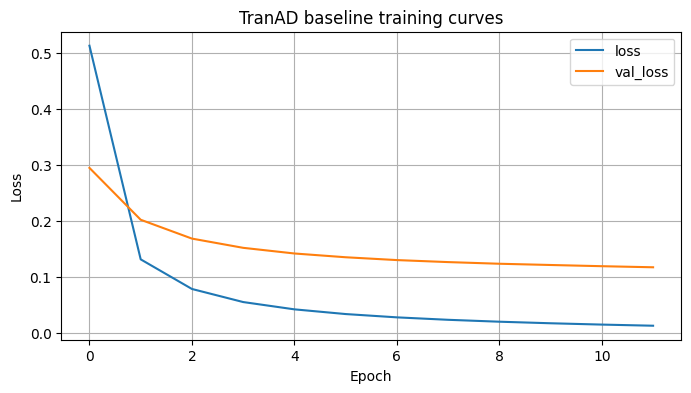

In [20]:
# Baseline training curves
history_df = pd.DataFrame(baseline_history.history)
history_df[['loss', 'val_loss']].plot(figsize=(8, 4), title='TranAD baseline training curves', grid=True)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [21]:
# --- Baseline model evaluation on the ground-truth synthetic test set ---
# 1) Synthetische dataset en labels inladen
synth_csv = f'../02_eda_en_ground_truth/processed/{GEBOUW}_test.csv'
labels_npy = f'../02_eda_en_ground_truth/processed/{GEBOUW}_test_labels.npy'

synth_df = pd.read_csv(synth_csv)
y_true_timestep = np.load(labels_npy).astype(int)

In [22]:
# 2) Kolommen alignen met training + normaliseren + windows maken
if 'timestamp' in synth_df.columns:
    synth_df = synth_df.drop(columns=['timestamp'])
for col in list(synth_df.columns):
    if col.lower().startswith('unnamed'):
        synth_df = synth_df.drop(columns=[col])

synth_df = synth_df[train_data.columns]
synth_norm = scaler.transform(synth_df)

STRIDE = 4
X_synth_baseline = create_windows(synth_norm, WINDOW_SIZE, step=STRIDE)

# Zet timestep labels om naar window labels
y_true_window_baseline = np.array([
    1 if np.max(y_true_timestep[i:i + WINDOW_SIZE]) > 0 else 0
    for i in range(0, len(y_true_timestep) - WINDOW_SIZE + 1, STRIDE)
], dtype=int)

print(f"Aligned synth shape: {synth_df.shape}")
print(f"Synthetische windows: {X_synth_baseline.shape}")
print(f"Window labels shape: {y_true_window_baseline.shape}, anomalies={int(y_true_window_baseline.sum())}")

Aligned synth shape: (461, 58)
Synthetische windows: (80, 144, 58)
Window labels shape: (80,), anomalies=58


In [23]:
# 3) Scores berekenen met baseline model (gebruik helper om juiste reconstructie te kiezen)
_, _, val_scores_baseline = score_windows_tranad(model, X_val, batch_size=BATCH_SIZE)

_, _, scores_synth_window_baseline = score_windows_tranad(model, X_synth_baseline, batch_size=BATCH_SIZE)

# 4) Threshold op basis van validatie (99e percentiel zoals encoder-only)
baseline_threshold = np.percentile(val_scores_baseline, 99)

# 5) Voorspellingen en basisstatistieken
y_pred_baseline = (scores_synth_window_baseline > baseline_threshold).astype(int)

print("val:", np.percentile(val_scores_baseline, [50, 90, 95, 99]))
print("eval:", np.percentile(scores_synth_window_baseline, [1, 5, 50, 95, 99]))
print("threshold:", baseline_threshold)
print("eval below threshold:", np.mean(scores_synth_window_baseline <= baseline_threshold))
print("shapes:", "y_true_window =", y_true_window_baseline.shape, "| y_pred_baseline =", y_pred_baseline.shape)

val: [ 8.03164988 10.18038197 12.37059579 12.47905224]
eval: [ 7.35445808  7.43654808 15.56138587 20.33655944 20.55404835]
threshold: 12.479052236543385
eval below threshold: 0.325
shapes: y_true_window = (80,) | y_pred_baseline = (80,)


In [24]:
# 6) Scorekaart (metrics + confusion matrix)
precision_b, recall_b, f1_b, _ = precision_recall_fscore_support(
    y_true_window_baseline, y_pred_baseline, average='binary', zero_division=0
)

cm_b = confusion_matrix(y_true_window_baseline, y_pred_baseline)

roc_auc_b = roc_auc_score(y_true_window_baseline, scores_synth_window_baseline)
pr_auc_b = average_precision_score(y_true_window_baseline, scores_synth_window_baseline)
accuracy_b = accuracy_score(y_true_window_baseline, y_pred_baseline)
balanced_acc_b = balanced_accuracy_score(y_true_window_baseline, y_pred_baseline)
mcc_b = matthews_corrcoef(y_true_window_baseline, y_pred_baseline)

metrics_b_df = pd.DataFrame({
    'Metric': [
        'Accuracy', 'Balanced Accuracy', 'Precision', 'Recall', 'F1', 'MCC', 'ROC-AUC', 'PR-AUC'
    ],
    'Value': [
        accuracy_b, balanced_acc_b, precision_b, recall_b, f1_b, mcc_b, roc_auc_b, pr_auc_b
    ]
})

print(metrics_b_df.to_string(index=False))
print('\nConfusion matrix:')
print(cm_b)

           Metric     Value
         Accuracy  0.575000
Balanced Accuracy  0.495298
        Precision  0.722222
           Recall  0.672414
               F1  0.696429
              MCC -0.008965
          ROC-AUC  0.294671
           PR-AUC  0.591921

Confusion matrix:
[[ 7 15]
 [19 39]]


/tmp/ipykernel_148484/1462325337.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metric_plot_df_b, x='Value', y='Metric', palette='viridis', ax=ax4)


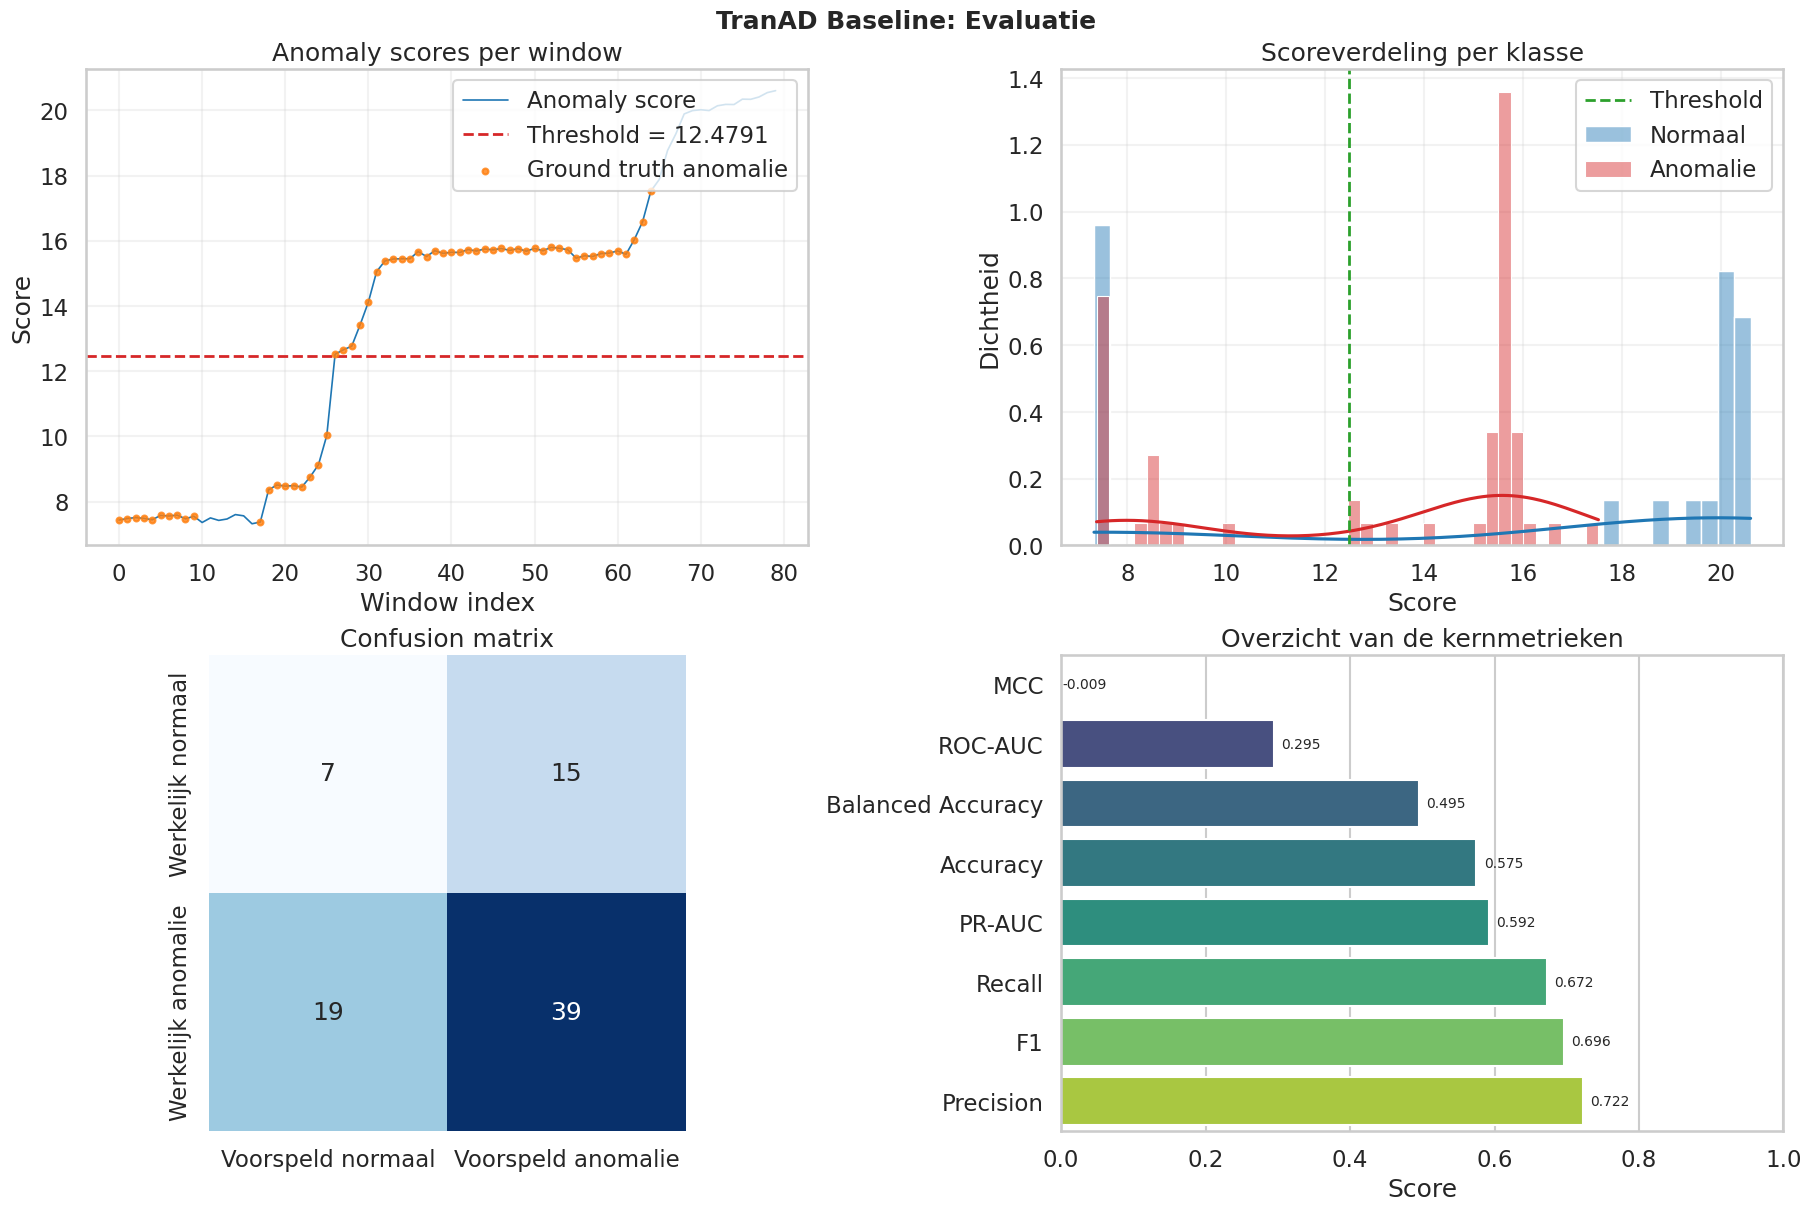

In [25]:
# 7) Visualisaties (zelfde style als encoder-only)
sns.set_theme(style='whitegrid', context='talk')
fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)
fig.suptitle('TranAD Baseline: Evaluatie', fontsize=18, fontweight='bold')

# Plot 1
ax1 = axes[0, 0]
ax1.plot(scores_synth_window_baseline, color='#1f77b4', linewidth=1.2, label='Anomaly score')
ax1.axhline(baseline_threshold, color='#d62728', linestyle='--', linewidth=2, label=f'Threshold = {baseline_threshold:.4f}')
anom_idx = np.where(y_true_window_baseline == 1)[0]
ax1.scatter(anom_idx, scores_synth_window_baseline[anom_idx], s=18, color='#ff7f0e', alpha=0.8, label='Ground truth anomalie', zorder=5)
ax1.set_title('Anomaly scores per window')
ax1.set_xlabel('Window index')
ax1.set_ylabel('Score')
ax1.legend(loc='upper right')
ax1.grid(alpha=0.25)

# Plot 2
ax2 = axes[0, 1]
sns.histplot(scores_synth_window_baseline[y_true_window_baseline == 0], bins=40, kde=True, stat='density', color='#1f77b4', alpha=0.45, label='Normaal', ax=ax2)
sns.histplot(scores_synth_window_baseline[y_true_window_baseline == 1], bins=40, kde=True, stat='density', color='#d62728', alpha=0.45, label='Anomalie', ax=ax2)
ax2.axvline(baseline_threshold, color='#2ca02c', linestyle='--', linewidth=2, label='Threshold')
ax2.set_title('Scoreverdeling per klasse')
ax2.set_xlabel('Score')
ax2.set_ylabel('Dichtheid')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.25)

# Plot 3
ax3 = axes[1, 0]
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Blues', cbar=False, square=True, xticklabels=['Voorspeld normaal', 'Voorspeld anomalie'], yticklabels=['Werkelijk normaal', 'Werkelijk anomalie'], ax=ax3)
ax3.set_title('Confusion matrix')
ax3.set_xlabel('')
ax3.set_ylabel('')

# Plot 4
ax4 = axes[1, 1]
metric_plot_df_b = metrics_b_df.sort_values('Value', ascending=True)
sns.barplot(data=metric_plot_df_b, x='Value', y='Metric', palette='viridis', ax=ax4)
for i, value in enumerate(metric_plot_df_b['Value']):
    ax4.text(min(value + 0.01, 1.02), i, f'{value:.3f}', va='center', fontsize=10)
ax4.set_xlim(0, max(1.0, metric_plot_df_b['Value'].max() + 0.15))
ax4.set_title('Overzicht van de kernmetrieken')
ax4.set_xlabel('Score')
ax4.set_ylabel('')

plt.show()

## STAP 4 - Hyperparameter tuning met KerasTuner

Deze stap is nu opgesplitst in atomaire cellen:

1. Zoekruimte + tuner opzetten
2. Beste model en hyperparameters ophalen
3. Evaluatieconfiguratie instellen
4. Testset voorbereiden
5. Scorekaart berekenen
6. Modelgewichten opslaan

In [26]:
def build_tranad_model(hp):
    d_model = hp.Choice('d_model', values=[96, 128, 160])
    num_heads = hp.Choice('num_heads', values=[4, 8])
    num_layers = hp.Int('num_layers', min_value=1, max_value=2)
    ffn_expansion = hp.Choice('ffn_expansion', values=[2, 4])
    dropout_rate = hp.Choice('dropout_rate', values=[0.0, 0.1, 0.2])
    alpha_phase1_start = hp.Choice('alpha_phase1_start', values=[0.5, 0.6, 0.7])
    alpha_phase1_end = hp.Choice('alpha_phase1_end', values=[0.05, 0.1, 0.2])
    lr = hp.Choice('learning_rate', values=[1e-3, 5e-4, 1e-4])

    model = TranAD(
        num_features=NUM_FEATURES,
        d_model=d_model,
        num_heads=num_heads,
        num_layers=num_layers,
        ffn_expansion=ffn_expansion,
        dropout_rate=dropout_rate,
        alpha_phase1_start=alpha_phase1_start,
        alpha_phase1_end=alpha_phase1_end,
        total_epochs=12,
    )

    _ = model(tf.zeros((1, WINDOW_SIZE, NUM_FEATURES), dtype=tf.float32))
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr))
    return model

tuner = kt.Hyperband(
    build_tranad_model,
    objective='val_loss',
    max_epochs=12,
    factor=3,
    directory='tuning_logs',
    project_name='tranad_keras_tuning',
)

print('Start TranAD hyperparameter tuning...')
tuner.search(
    train_dataset,
    validation_data=val_dataset,
    callbacks=[
        TranADPhaseScheduler(total_epochs=12),
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3),
    ],
)

Reloading Tuner from tuning_logs/tranad_keras_tuning/tuner0.json
Start TranAD hyperparameter tuning...


In [27]:
# Beste trial ophalen en model compileerbaar maken
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.get_best_models(num_models=1)[0]

auto_lr = best_hps.values.get('learning_rate', LEARNING_RATE)
best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=auto_lr))

# Aliassen voor compatibiliteit met bestaande cellen
final_model = best_model
loaded_model = best_model

print('\nBeste configuratie gevonden:')
print(best_hps.values)


Beste configuratie gevonden:
{'d_model': 160, 'num_heads': 4, 'num_layers': 1, 'ffn_expansion': 4, 'dropout_rate': 0.2, 'alpha_phase1': 0.4, 'learning_rate': 0.001, 'tuner/epochs': 12, 'tuner/initial_epoch': 4, 'tuner/bracket': 1, 'tuner/round': 1, 'tuner/trial_id': '0019', 'alpha_phase1_start': 0.5, 'alpha_phase1_end': 0.05}


/home/jakob/Documents/vscode/hogent/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 156 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [28]:
# Uniforme evaluatieconfiguratie (zelfde concepten als encoder-only)
LABEL_MODE = 'fraction'          # 'max' | 'center' | 'fraction'
LABEL_FRACTION_THRESHOLD = 0.20
SCORE_MODE = 'quantile_l1_sum'   # 'mean_l1_sum' | 'quantile_l1_sum' | 'lastk_l1_sum'
SCORE_QUANTILE = 0.90
SCORE_LAST_K = 24
STRIDE = 1

print('Evaluatieconfiguratie actief.')

Evaluatieconfiguratie actief.


In [29]:
# Gelabelde synthetische testset inladen en aligneren
test_synth_csv = f'../02_eda_en_ground_truth/processed/{GEBOUW}_test.csv'
test_labels_npy = f'../02_eda_en_ground_truth/processed/{GEBOUW}_test_labels.npy'

synth_df = pd.read_csv(test_synth_csv)
y_true_timestep = np.load(test_labels_npy).astype(int)

if 'timestamp' in synth_df.columns:
    synth_df = synth_df.drop(columns=['timestamp'])
for col in list(synth_df.columns):
    if col.lower().startswith('unnamed'):
        synth_df = synth_df.drop(columns=[col])

synth_df = synth_df[train_data.columns]
synth_norm = scaler.transform(synth_df)

X_synth_best = create_windows(synth_norm, WINDOW_SIZE, step=STRIDE)
y_true_window_best = make_window_labels(
    y_true_timestep,
    window_size=WINDOW_SIZE,
    stride=STRIDE,
    mode=LABEL_MODE,
    frac_threshold=LABEL_FRACTION_THRESHOLD,
)

# Alias voor downstream-cellen
y_true_window = y_true_window_best

print(f'Aligned synth shape: {synth_df.shape}')
print(f'Synthetische windows: {X_synth_best.shape}')
print(f'Window labels shape: {y_true_window_best.shape}, anomalies={int(y_true_window_best.sum())}')

Aligned synth shape: (461, 58)
Synthetische windows: (318, 144, 58)
Window labels shape: (318,), anomalies=109


In [30]:
# Scores berekenen en baseline-scorekaart opstellen
_, _, val_scores_best = score_windows_tranad(
    best_model,
    X_val,
    batch_size=BATCH_SIZE,
    score_mode=SCORE_MODE,
    quantile=SCORE_QUANTILE,
    last_k=SCORE_LAST_K,
)
_, _, scores_synth_window_best = score_windows_tranad(
    best_model,
    X_synth_best,
    batch_size=BATCH_SIZE,
    score_mode=SCORE_MODE,
    quantile=SCORE_QUANTILE,
    last_k=SCORE_LAST_K,
)

# Aliassen voor bestaande visualisatiecellen
eval_scores_best = scores_synth_window_best
scores_synth_window = scores_synth_window_best

baseline_threshold_best = np.percentile(val_scores_best, 99.5)
baseline_result = build_reusable_scorecard(
    y_true_window_best,
    scores_synth_window_best,
    threshold=baseline_threshold_best,
    model_name='TranAD-best-baseline',
)

y_pred_eval_best = baseline_result['y_pred_window']
metrics_best_df = baseline_result['metrics_df']
cm_best = baseline_result['confusion_matrix']

precision_best = float(metrics_best_df.loc[metrics_best_df['Metric'] == 'Precision', 'Value'].iloc[0])
recall_best = float(metrics_best_df.loc[metrics_best_df['Metric'] == 'Recall', 'Value'].iloc[0])
f1_best = float(metrics_best_df.loc[metrics_best_df['Metric'] == 'F1', 'Value'].iloc[0])
accuracy_best = float(metrics_best_df.loc[metrics_best_df['Metric'] == 'Accuracy', 'Value'].iloc[0])
balanced_acc_best = float(metrics_best_df.loc[metrics_best_df['Metric'] == 'Balanced Accuracy', 'Value'].iloc[0])
mcc_best = float(metrics_best_df.loc[metrics_best_df['Metric'] == 'MCC', 'Value'].iloc[0])
roc_auc_best = float(metrics_best_df.loc[metrics_best_df['Metric'] == 'ROC-AUC', 'Value'].iloc[0])
pr_auc_best = float(metrics_best_df.loc[metrics_best_df['Metric'] == 'PR-AUC', 'Value'].iloc[0])

print('val:', np.percentile(val_scores_best, [50, 90, 95, 99, 99.5]))
print('eval:', np.percentile(scores_synth_window_best, [1, 5, 50, 95, 99]))
print('threshold:', baseline_threshold_best)
print('eval below threshold:', np.mean(scores_synth_window_best <= baseline_threshold_best))
print('shapes:', 'y_true_window =', y_true_window_best.shape, '| y_pred_eval_best =', y_pred_eval_best.shape)

print('\nScorekaart (window + event):')
print(metrics_best_df.to_string(index=False))
print('\nConfusion matrix:')
print(cm_best)
print('\nEvent details:')
print(baseline_result['event_details'])

val: [2.39950602 5.6883106  5.84175331 5.98622673 6.00078528]
eval: [ 3.78284251  3.79905347  5.78224654 10.03993684 10.04777762]
threshold: 6.000785277451152
eval below threshold: 0.5188679245283019
shapes: y_true_window = (318,) | y_pred_eval_best = (318,)

Scorekaart (window + event):
               Model            Metric    Value
TranAD-best-baseline          Accuracy 0.798742
TranAD-best-baseline Balanced Accuracy 0.824942
TranAD-best-baseline         Precision 0.647059
TranAD-best-baseline            Recall 0.908257
TranAD-best-baseline                F1 0.755725
TranAD-best-baseline               MCC 0.617354
TranAD-best-baseline           ROC-AUC 0.909705
TranAD-best-baseline            PR-AUC 0.923045
TranAD-best-baseline   Event Precision 1.000000
TranAD-best-baseline      Event Recall 0.500000
TranAD-best-baseline          Event F1 0.666667

Confusion matrix:
[[155  54]
 [ 10  99]]

Event details:
{'event_precision': 1.0, 'event_recall': 0.5, 'event_f1': 0.6666666666666666,

In [31]:
# Beste model opslaan (idempotent)
gebouw_naam = GEBOUW
huidige_datum = datetime.now().strftime('%Y-%m-%d')
model_dir = 'models'
os.makedirs(model_dir, exist_ok=True)
save_path = f"{model_dir}/tranad-{gebouw_naam}-{huidige_datum}-best.weights.h5"
best_model.save_weights(save_path)

print(f'Beste TranAD model succesvol opgeslagen in: {save_path}')

Beste TranAD model succesvol opgeslagen in: models/tranad-dunant1-2026-05-05-best.weights.h5


## STAP 5 - Threshold-kalibratie op hold-out split

Na de uniforme baseline-scorekaart volgt een strengere kalibratie:

1. Herlaad het beste model
2. Bepaal baseline-threshold op validatie
3. Splits gelabelde windows in calibration en hold-out
4. Tune threshold op calibration
5. Rapporteer finale hold-out scorekaart

In [32]:
# Model opnieuw opbouwen met beste hyperparameters en gewichten laden
best_params = best_hps.values

loaded_model = TranAD(
    num_features=NUM_FEATURES,
    d_model=best_params['d_model'],
    num_heads=best_params['num_heads'],
    num_layers=best_params['num_layers'],
    ffn_expansion=best_params['ffn_expansion'],
    dropout_rate=best_params['dropout_rate'],
    alpha_phase1_start=best_params.get('alpha_phase1_start', ALPHA_PHASE1_START),
    alpha_phase1_end=best_params.get('alpha_phase1_end', ALPHA_PHASE1_END),
    total_epochs=NUM_EPOCHS,
 )

_ = loaded_model(tf.zeros((1, WINDOW_SIZE, NUM_FEATURES), dtype=tf.float32))
loaded_model.load_weights(save_path)
loaded_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']))

print('Beste TranAD modelgewichten succesvol ingeladen.')

Beste TranAD modelgewichten succesvol ingeladen.


In [33]:
# Baseline threshold kalibreren op validatiescores
_, _, val_scores_best = score_windows_tranad(
    best_model,
    X_val,
    batch_size=BATCH_SIZE,
    score_mode=SCORE_MODE,
    quantile=SCORE_QUANTILE,
    last_k=SCORE_LAST_K,
 )
baseline_threshold_best = np.percentile(val_scores_best, 99.5)

print('val:', np.percentile(val_scores_best, [50, 90, 95, 99, 99.5]))
print('baseline threshold:', baseline_threshold_best)

val: [2.39950602 5.6883106  5.84175331 5.98622673 6.00078528]
baseline threshold: 6.000785277451152


In [34]:
# Gelabelde synthetische evaluatieset inladen
synth_csv = f'../02_eda_en_ground_truth/processed/{GEBOUW}_test.csv'
labels_npy = f'../02_eda_en_ground_truth/processed/{GEBOUW}_test_labels.npy'

synth_df = pd.read_csv(synth_csv)
y_true_timestep = np.load(labels_npy).astype(int)

In [35]:
# 1) Synthetische dataset en labels inladen (exact pad zoals encoder-only)
if 'timestamp' in synth_df.columns:
    synth_df = synth_df.drop(columns=['timestamp'])
for col in list(synth_df.columns):
    if col.lower().startswith('unnamed'):
        synth_df = synth_df.drop(columns=[col])

synth_df = synth_df[train_data.columns]
synth_norm = scaler.transform(synth_df)

STRIDE = 6
X_synth_best = create_windows(synth_norm, WINDOW_SIZE, step=STRIDE)
y_true_window_best = make_window_labels(
    y_true_timestep,
    window_size=WINDOW_SIZE,
    stride=STRIDE,
    mode=LABEL_MODE,
    frac_threshold=LABEL_FRACTION_THRESHOLD,
 )

print(f"Aligned synth shape: {synth_df.shape}")
print(f"Synthetische windows: {X_synth_best.shape}")
print(f"Window labels shape: {y_true_window_best.shape}, anomalies={int(y_true_window_best.sum())}")

# 2) Scores op de volledige ground-truth windows berekenen
_, _, scores_synth_window_best = score_windows_tranad(
    best_model,
    X_synth_best,
    batch_size=BATCH_SIZE,
    score_mode=SCORE_MODE,
    quantile=SCORE_QUANTILE,
    last_k=SCORE_LAST_K,
 )

# Aliassen voor de bestaande visualisatiecellen
scores_synth_window = scores_synth_window_best

# 3) Threshold-tuning op een calibration split uit de ground-truth windows
split_idx = int(len(scores_synth_window_best) * 0.6)
scores_tune = scores_synth_window_best[:split_idx]
y_tune = y_true_window_best[:split_idx]
scores_eval = scores_synth_window_best[split_idx:]
y_eval = y_true_window_best[split_idx:]

if len(np.unique(y_tune)) < 2:
    tuned_threshold_best = np.percentile(scores_tune, 99.5)
    best_candidate_f1 = np.nan
else:
    tuned_threshold_best, best_candidate_f1 = tune_threshold_by_f1(scores_tune, y_tune, q_low=0.90, q_high=0.999, n=250)

# Aliassen voor de rest van de evaluatie
baseline_threshold = baseline_threshold_best
eval_scores_best = scores_eval
y_true_window = y_eval

# 4) Voorspellingen op de evaluatiesplit
y_pred_eval_best = (eval_scores_best > tuned_threshold_best).astype(int)

print('baseline threshold:', baseline_threshold_best)
print('tuned threshold:', tuned_threshold_best)
print('tune below threshold:', np.mean(scores_tune <= tuned_threshold_best))
print('eval below threshold:', np.mean(eval_scores_best <= tuned_threshold_best))
print('shapes:', 'y_true_window =', y_true_window.shape, '| y_pred_eval_best =', y_pred_eval_best.shape)

Aligned synth shape: (461, 58)
Synthetische windows: (53, 144, 58)
Window labels shape: (53,), anomalies=19
baseline threshold: 6.000785277451152
tuned threshold: 10.035935950128188
tune below threshold: 0.9032258064516129
eval below threshold: 0.8636363636363636
shapes: y_true_window = (22,) | y_pred_eval_best = (22,)


            Model            Metric    Value
TranAD-best-tuned          Accuracy 0.909091
TranAD-best-tuned Balanced Accuracy 0.800000
TranAD-best-tuned         Precision 1.000000
TranAD-best-tuned            Recall 0.600000
TranAD-best-tuned                F1 0.750000
TranAD-best-tuned               MCC 0.732695
TranAD-best-tuned           ROC-AUC 1.000000
TranAD-best-tuned            PR-AUC 1.000000
TranAD-best-tuned   Event Precision 1.000000
TranAD-best-tuned      Event Recall 1.000000
TranAD-best-tuned          Event F1 1.000000

Confusion matrix:
[[17  0]
 [ 2  3]]

Event details:
{'event_precision': 1.0, 'event_recall': 1.0, 'event_f1': 1.0, 'n_true_events': 1, 'n_pred_events': 2, 'matched_true_events': 1, 'matched_pred_events': 2}


/tmp/ipykernel_148484/3768610374.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metric_plot_df_b, x='Value', y='Metric', palette='viridis', ax=ax4)


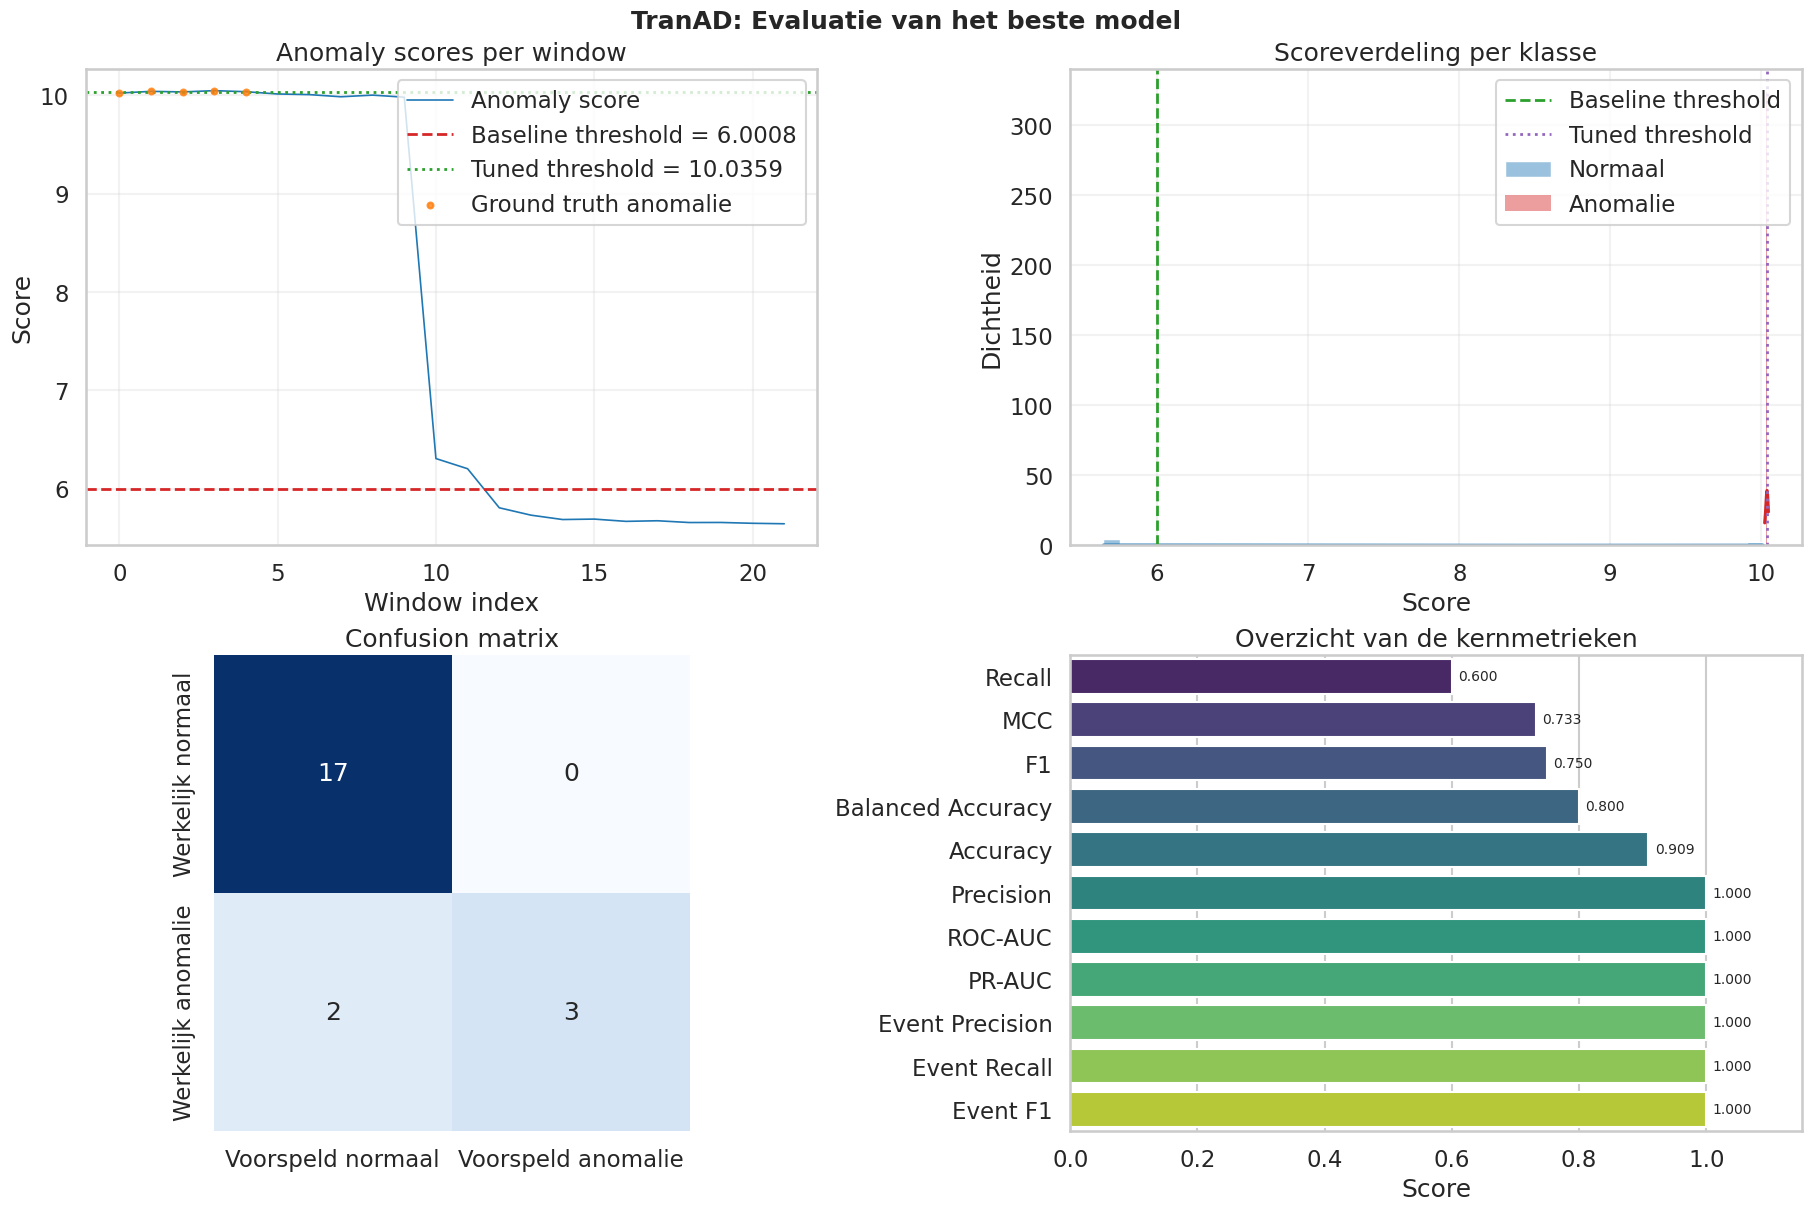

In [36]:
# 5) Herbruikbare scorekaart (window + event) op hold-out evaluatiesplit
tuned_result = build_reusable_scorecard(
    y_true_window,
    eval_scores_best,
    threshold=tuned_threshold_best,
    model_name='TranAD-best-tuned',
)

metrics_best_df = tuned_result['metrics_df']
cm_best = tuned_result['confusion_matrix']
y_pred_eval_best = tuned_result['y_pred_window']

# Voor downstream compatibiliteit
precision_best = float(metrics_best_df.loc[metrics_best_df['Metric'] == 'Precision', 'Value'].iloc[0])
recall_best = float(metrics_best_df.loc[metrics_best_df['Metric'] == 'Recall', 'Value'].iloc[0])
f1_best = float(metrics_best_df.loc[metrics_best_df['Metric'] == 'F1', 'Value'].iloc[0])
accuracy_best = float(metrics_best_df.loc[metrics_best_df['Metric'] == 'Accuracy', 'Value'].iloc[0])
balanced_acc_best = float(metrics_best_df.loc[metrics_best_df['Metric'] == 'Balanced Accuracy', 'Value'].iloc[0])
mcc_best = float(metrics_best_df.loc[metrics_best_df['Metric'] == 'MCC', 'Value'].iloc[0])
roc_auc_best = float(metrics_best_df.loc[metrics_best_df['Metric'] == 'ROC-AUC', 'Value'].iloc[0])
pr_auc_best = float(metrics_best_df.loc[metrics_best_df['Metric'] == 'PR-AUC', 'Value'].iloc[0])

print(metrics_best_df.to_string(index=False))
print('\nConfusion matrix:')
print(cm_best)
print('\nEvent details:')
print(tuned_result['event_details'])

# Visualisaties (zelfde layout als encoder-only)
sns.set_theme(style='whitegrid', context='talk')

fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)
fig.suptitle('TranAD: Evaluatie van het beste model', fontsize=18, fontweight='bold')

# Plot 1: anomaly scores over de windows
ax1 = axes[0, 0]
ax1.plot(eval_scores_best, color='#1f77b4', linewidth=1.2, label='Anomaly score')
ax1.axhline(baseline_threshold_best, color='#d62728', linestyle='--', linewidth=2, label=f'Baseline threshold = {baseline_threshold_best:.4f}')
ax1.axhline(tuned_threshold_best, color='#2ca02c', linestyle=':', linewidth=2, label=f'Tuned threshold = {tuned_threshold_best:.4f}')

anom_idx = np.where(y_true_window == 1)[0]
ax1.scatter(
    anom_idx,
    eval_scores_best[anom_idx],
    s=18,
    color='#ff7f0e',
    alpha=0.8,
    label='Ground truth anomalie',
    zorder=5
)

ax1.set_title('Anomaly scores per window')
ax1.set_xlabel('Window index')
ax1.set_ylabel('Score')
ax1.legend(loc='upper right')
ax1.grid(alpha=0.25)

# Plot 2: scoreverdeling per klasse
ax2 = axes[0, 1]
sns.histplot(eval_scores_best[y_true_window == 0], bins=40, kde=True, stat='density', color='#1f77b4', alpha=0.45, label='Normaal', ax=ax2)
sns.histplot(eval_scores_best[y_true_window == 1], bins=40, kde=True, stat='density', color='#d62728', alpha=0.45, label='Anomalie', ax=ax2)
ax2.axvline(baseline_threshold_best, color='#2ca02c', linestyle='--', linewidth=2, label='Baseline threshold')
ax2.axvline(tuned_threshold_best, color='#9467bd', linestyle=':', linewidth=2, label='Tuned threshold')
ax2.set_title('Scoreverdeling per klasse')
ax2.set_xlabel('Score')
ax2.set_ylabel('Dichtheid')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.25)

# Plot 3: confusion matrix
ax3 = axes[1, 0]
sns.heatmap(
    cm_best,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    square=True,
    xticklabels=['Voorspeld normaal', 'Voorspeld anomalie'],
    yticklabels=['Werkelijk normaal', 'Werkelijk anomalie'],
    ax=ax3
)
ax3.set_title('Confusion matrix')
ax3.set_xlabel('')
ax3.set_ylabel('')

# Plot 4: metric overview
ax4 = axes[1, 1]
metric_plot_df_b = metrics_best_df.sort_values('Value', ascending=True)
sns.barplot(data=metric_plot_df_b, x='Value', y='Metric', palette='viridis', ax=ax4)
for i, value in enumerate(metric_plot_df_b['Value']):
    ax4.text(min(value + 0.01, 1.02), i, f'{value:.3f}', va='center', fontsize=10)
ax4.set_xlim(0, max(1.0, metric_plot_df_b['Value'].max() + 0.15))
ax4.set_title('Overzicht van de kernmetrieken')
ax4.set_xlabel('Score')
ax4.set_ylabel('')

plt.show()

In [37]:
print(f'Baseline threshold (validation): {baseline_threshold_best:.4f}')
print(f'Tuned threshold (ground-truth split): {tuned_threshold_best:.4f}')
print(f'Hold-out anomaly rate predicted: {np.mean(y_pred_eval_best):.4f}')

Baseline threshold (validation): 6.0008
Tuned threshold (ground-truth split): 10.0359
Hold-out anomaly rate predicted: 0.1364


## STAP 7 - Scorekaart en visualisaties

We rapporteren nu de prestaties van het beste TranAD-model op de hold-out evaluatiesplit. De threshold komt uit een calibration split van de ground-truth windows, zodat de scorekaart zinvol blijft wanneer de validatiedrempel te laag blijkt.

In [38]:
# Extra output: classification report op de hold-out split
print(classification_report(y_true_window, y_pred_eval_best, digits=4, zero_division=0))

              precision    recall  f1-score   support

           0     0.8947    1.0000    0.9444        17
           1     1.0000    0.6000    0.7500         5

    accuracy                         0.9091        22
   macro avg     0.9474    0.8000    0.8472        22
weighted avg     0.9187    0.9091    0.9003        22



In [39]:
fpr, tpr, _ = roc_curve(y_true_window, eval_scores_best)
prec_curve, rec_curve, _ = precision_recall_curve(y_true_window, eval_scores_best)

print(f'ROC-AUC={roc_auc_best:.4f} | PR-AUC={pr_auc_best:.4f}')

ROC-AUC=1.0000 | PR-AUC=1.0000


/tmp/ipykernel_148484/3232061750.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


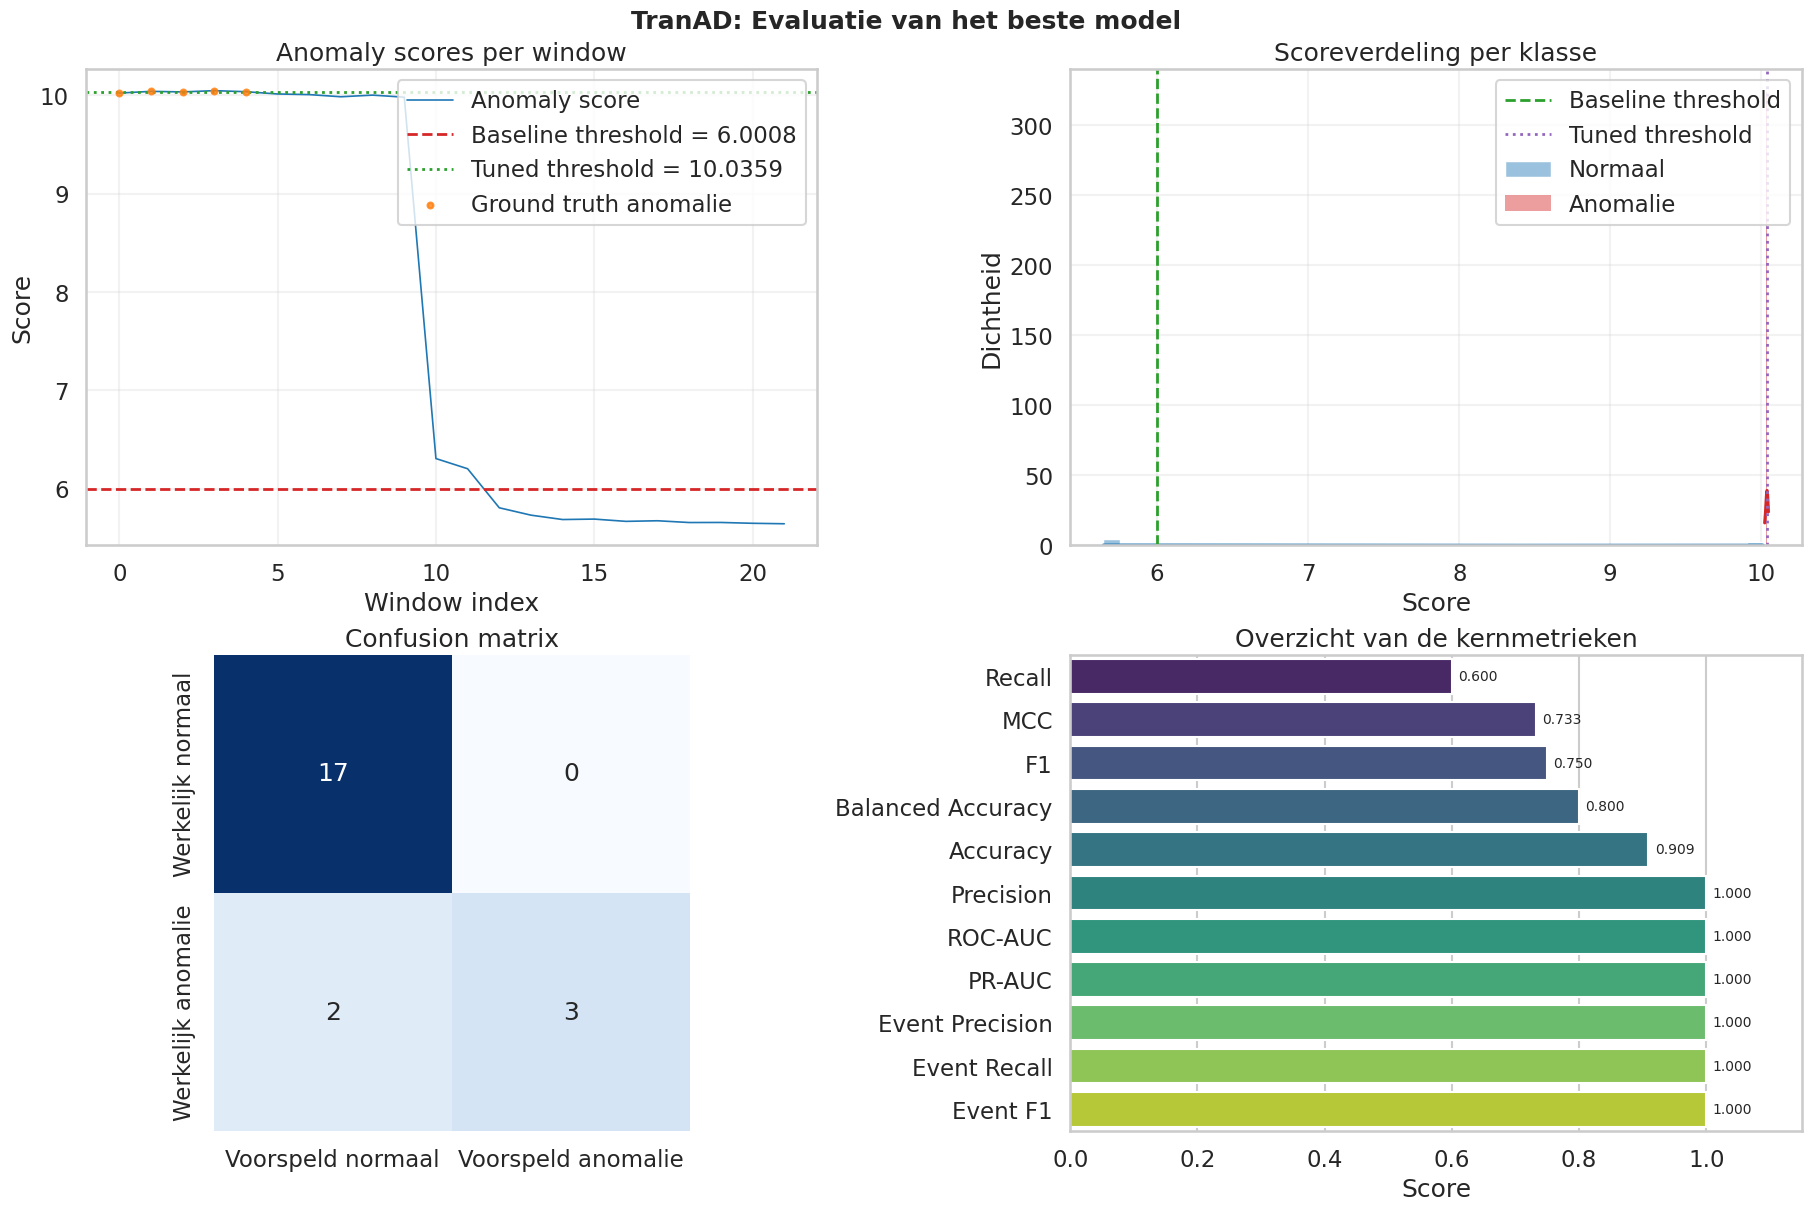

In [40]:
sns.set_theme(style='whitegrid', context='talk')

fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)
fig.suptitle('TranAD: Evaluatie van het beste model', fontsize=18, fontweight='bold')

# Plot 1: anomaly scores per window
ax1 = axes[0, 0]
ax1.plot(eval_scores_best, color='#1f77b4', linewidth=1.2, label='Anomaly score')
ax1.axhline(
    baseline_threshold_best,
    color='#d62728',
    linestyle='--',
    linewidth=2,
    label=f'Baseline threshold = {baseline_threshold_best:.4f}',
)
ax1.axhline(
    tuned_threshold_best,
    color='#2ca02c',
    linestyle=':',
    linewidth=2,
    label=f'Tuned threshold = {tuned_threshold_best:.4f}',
)

anom_idx = np.where(y_true_window == 1)[0]
ax1.scatter(
    anom_idx,
    eval_scores_best[anom_idx],
    s=18,
    color='#ff7f0e',
    alpha=0.8,
    label='Ground truth anomalie',
    zorder=5,
)

ax1.set_title('Anomaly scores per window')
ax1.set_xlabel('Window index')
ax1.set_ylabel('Score')
ax1.legend(loc='upper right')
ax1.grid(alpha=0.25)

# Plot 2: scoreverdeling per klasse
ax2 = axes[0, 1]
sns.histplot(
    eval_scores_best[y_true_window == 0],
    bins=40,
    kde=True,
    stat='density',
    color='#1f77b4',
    alpha=0.45,
    label='Normaal',
    ax=ax2,
)
sns.histplot(
    eval_scores_best[y_true_window == 1],
    bins=40,
    kde=True,
    stat='density',
    color='#d62728',
    alpha=0.45,
    label='Anomalie',
    ax=ax2,
)
ax2.axvline(baseline_threshold_best, color='#2ca02c', linestyle='--', linewidth=2, label='Baseline threshold')
ax2.axvline(tuned_threshold_best, color='#9467bd', linestyle=':', linewidth=2, label='Tuned threshold')
ax2.set_title('Scoreverdeling per klasse')
ax2.set_xlabel('Score')
ax2.set_ylabel('Dichtheid')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.25)

# Plot 3: confusion matrix
ax3 = axes[1, 0]
sns.heatmap(
    cm_best,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    square=True,
    xticklabels=['Voorspeld normaal', 'Voorspeld anomalie'],
    yticklabels=['Werkelijk normaal', 'Werkelijk anomalie'],
    ax=ax3,
)
ax3.set_title('Confusion matrix')
ax3.set_xlabel('')
ax3.set_ylabel('')

# Plot 4: metric overview
ax4 = axes[1, 1]
metric_plot_df = metrics_best_df.sort_values('Value', ascending=True)

sns.barplot(
    data=metric_plot_df,
    x='Value',
    y='Metric',
    palette='viridis',
    ax=ax4,
)

for i, value in enumerate(metric_plot_df['Value']):
    ax4.text(min(value + 0.01, 1.02), i, f'{value:.3f}', va='center', fontsize=10)

ax4.set_xlim(0, max(1.0, metric_plot_df['Value'].max() + 0.15))
ax4.set_title('Overzicht van de kernmetrieken')
ax4.set_xlabel('Score')
ax4.set_ylabel('')

plt.show()

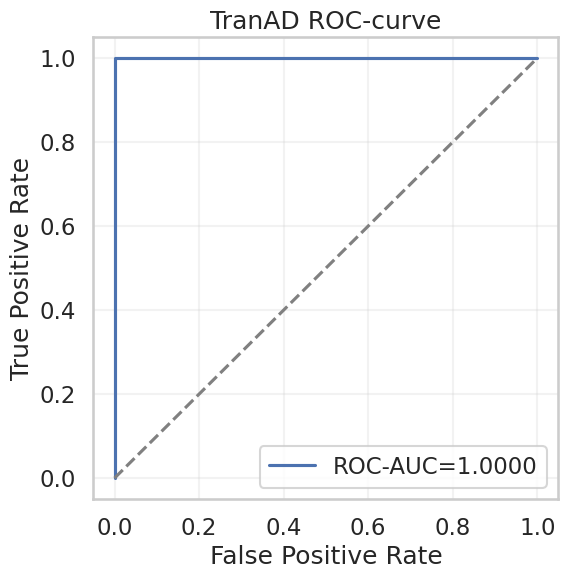

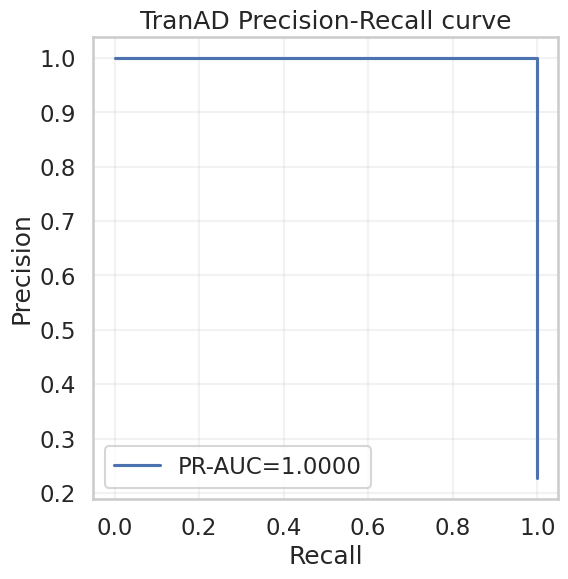

In [41]:
# Extra ROC en PR-curves
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'ROC-AUC={roc_auc_best:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('TranAD ROC-curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

plt.figure(figsize=(6, 6))
plt.plot(rec_curve, prec_curve, label=f'PR-AUC={pr_auc_best:.4f}')
plt.title('TranAD Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(alpha=0.25)
plt.legend()
plt.show()